In [45]:
import os, gc
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from inspect import getfile, getsource
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    DiffusionPipeline,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel,
)
import torch
from transformers import AutoTokenizer, PretrainedConfig
from safetensors.torch import load_file


In [40]:
# pretrained_model_name_or_path = "stablediffusionapi/chilloutmix"
pretrained_model_name_or_path = "CompVis/stable-diffusion-v1-4"
pipeline = DiffusionPipeline.from_pretrained(pretrained_model_name_or_path, torch_dtype=torch.float16)


device = "cuda:0"
pipeline.scheduler = DDIMScheduler.from_config(pipeline.scheduler.config)
pipeline.safety_checker = None
pipeline.requires_safety_checker = False
pipeline = pipeline.to("cuda:2")
pipeline.set_progress_bar_config(disable=True)
    

/home/nessessence/anaconda3/envs/mace/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100%|██████████████████████████████████| 7/7 [00:04<00:00,  1.49it/s]


In [41]:
import torch
import matplotlib.pyplot as plt

def display_cfg_variation_grid(pipeline, base_seed, cfg_scales, num_gen_img=5, prompt="A photo of a crybaby art toy", device="cuda"):
    """
    Displays a grid of images: rows = different seeds, columns = different cfg_scales
    """
    fig, axs = plt.subplots(num_gen_img, len(cfg_scales), figsize=(3 * len(cfg_scales), 3 * num_gen_img))
    if num_gen_img == 1:
        axs = [axs]  # Make iterable

    for row in range(num_gen_img):
        seed = base_seed + row  # Different seed per row
        for col, cfg in enumerate(cfg_scales):
            generator = torch.Generator(device=device).manual_seed(seed)
            image = pipeline(prompt, generator=generator, guidance_scale=cfg).images[0]

            ax = axs[row][col] if num_gen_img > 1 else axs[col]
            ax.imshow(image)
            ax.axis("off")
            if row == 0:
                ax.set_title(f"CFG: {cfg}")

    plt.tight_layout()
    plt.show()


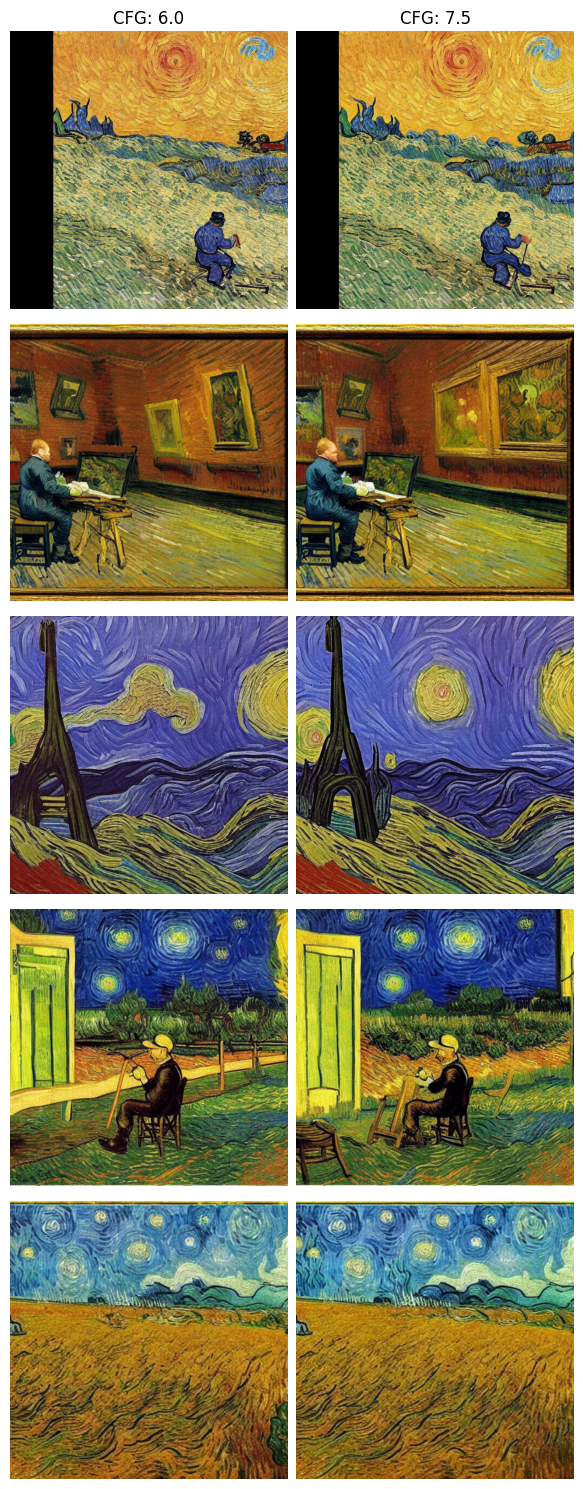

In [43]:
prompt = "A photo of van Gogh painting a landscape, highly detailed, vibrant colors"
cfg_scales = [6.0,7.5]
base_seed = 0
display_cfg_variation_grid(pipeline ,  base_seed=base_seed, cfg_scales=cfg_scales,prompt=prompt, num_gen_img=5)

In [47]:
esd_weights = load_file("esd/esd-models/sd/esd-Van_Gogh-from-Van_Gogh-esdu.safetensors")
pipeline.unet.load_state_dict(esd_weights, strict=False)


_IncompatibleKeys(missing_keys=['down_blocks.0.attentions.0.norm.weight', 'down_blocks.0.attentions.0.norm.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.norm1.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm1.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.norm2.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm2.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.norm3.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm3.bias', 'down_blocks.0.attentions.1.norm.weight', 'down_blocks.0.attentions.1.norm.bias', 'down_blocks.0.attentions.1.transformer_blocks.0.norm1.weight', 'down_block

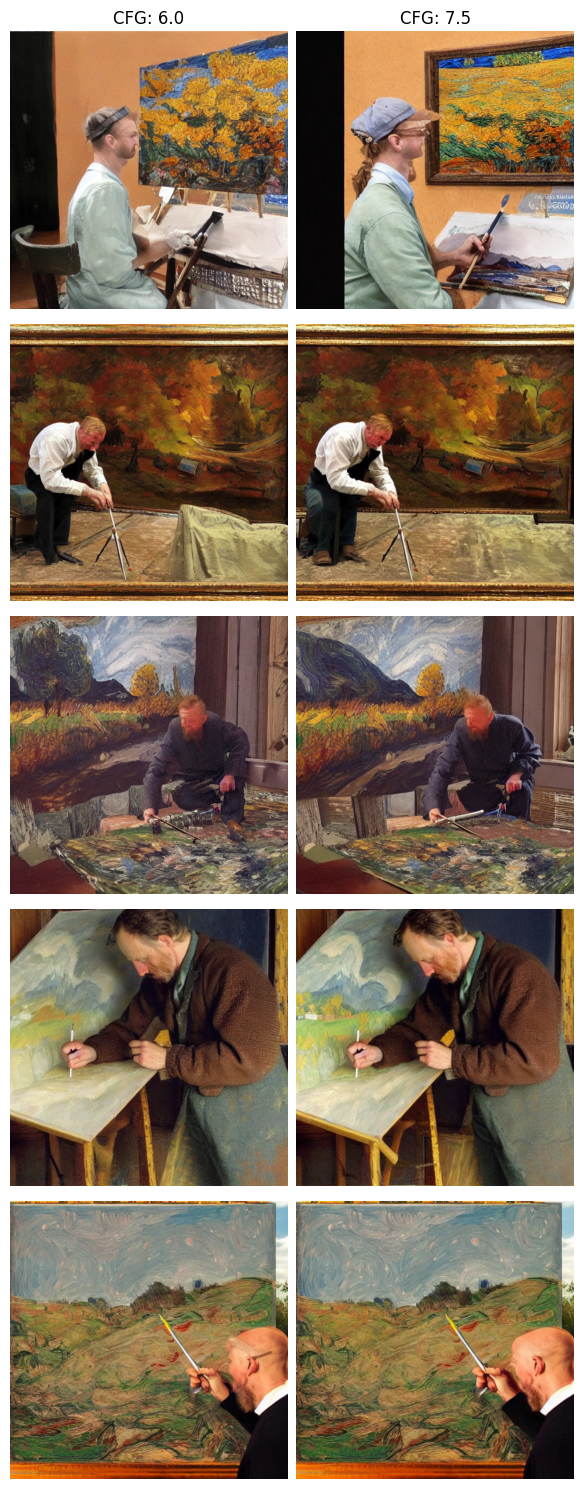

In [48]:
prompt = "A photo of van Gogh painting a landscape, highly detailed, vibrant colors"
cfg_scales = [6.0,7.5]
base_seed = 0
display_cfg_variation_grid(pipeline ,  base_seed=base_seed, cfg_scales=cfg_scales,prompt=prompt, num_gen_img=5)

In [60]:
for module in esd_weights.keys():
    if 'attn2' in module:
        print(module)
        print(esd_weights[module].shape)
        print()
    if 'attn1' in module:
        print(module)
        print(esd_weights[module].shape)
        print()
    if 'res' in module:
        print(module)
        print(esd_weights[module].shape)
        print()

down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_k.weight
torch.Size([320, 320])

down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.bias
torch.Size([320])

down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_out.0.weight
torch.Size([320, 320])

down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_q.weight
torch.Size([320, 320])

down_blocks.0.attentions.0.transformer_blocks.0.attn1.to_v.weight
torch.Size([320, 320])

down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_k.weight
torch.Size([320, 320])

down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_out.0.bias
torch.Size([320])

down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_out.0.weight
torch.Size([320, 320])

down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_q.weight
torch.Size([320, 320])

down_blocks.0.attentions.1.transformer_blocks.0.attn1.to_v.weight
torch.Size([320, 320])

down_blocks.0.resnets.0.conv1.bias
torch.Size([320])

down_blocks.0.resnets.0.conv1.weight
torch.S

In [59]:
missing_keys=['down_blocks.0.attentions.0.norm.weight', 'down_blocks.0.attentions.0.norm.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.norm1.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm1.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.norm2.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm2.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'down_blocks.0.attentions.0.transformer_blocks.0.norm3.weight', 'down_blocks.0.attentions.0.transformer_blocks.0.norm3.bias', 'down_blocks.0.attentions.1.norm.weight', 'down_blocks.0.attentions.1.norm.bias', 'down_blocks.0.attentions.1.transformer_blocks.0.norm1.weight', 'down_blocks.0.attentions.1.transformer_blocks.0.norm1.bias', 'down_blocks.0.attentions.1.transformer_blocks.0.norm2.weight', 'down_blocks.0.attentions.1.transformer_blocks.0.norm2.bias', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_q.weight', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_k.weight', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_v.weight', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_out.0.weight', 'down_blocks.0.attentions.1.transformer_blocks.0.attn2.to_out.0.bias', 'down_blocks.0.attentions.1.transformer_blocks.0.norm3.weight', 'down_blocks.0.attentions.1.transformer_blocks.0.norm3.bias', 'down_blocks.0.resnets.0.norm1.weight', 'down_blocks.0.resnets.0.norm1.bias', 'down_blocks.0.resnets.0.norm2.weight', 'down_blocks.0.resnets.0.norm2.bias', 'down_blocks.0.resnets.1.norm1.weight', 'down_blocks.0.resnets.1.norm1.bias', 'down_blocks.0.resnets.1.norm2.weight', 'down_blocks.0.resnets.1.norm2.bias', 'down_blocks.1.attentions.0.norm.weight', 'down_blocks.1.attentions.0.norm.bias', 'down_blocks.1.attentions.0.transformer_blocks.0.norm1.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.norm1.bias', 'down_blocks.1.attentions.0.transformer_blocks.0.norm2.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.norm2.bias', 'down_blocks.1.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'down_blocks.1.attentions.0.transformer_blocks.0.norm3.weight', 'down_blocks.1.attentions.0.transformer_blocks.0.norm3.bias', 'down_blocks.1.attentions.1.norm.weight', 'down_blocks.1.attentions.1.norm.bias', 'down_blocks.1.attentions.1.transformer_blocks.0.norm1.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.norm1.bias', 'down_blocks.1.attentions.1.transformer_blocks.0.norm2.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.norm2.bias', 'down_blocks.1.attentions.1.transformer_blocks.0.attn2.to_q.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.attn2.to_k.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.attn2.to_v.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.attn2.to_out.0.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.attn2.to_out.0.bias', 'down_blocks.1.attentions.1.transformer_blocks.0.norm3.weight', 'down_blocks.1.attentions.1.transformer_blocks.0.norm3.bias', 'down_blocks.1.resnets.0.norm1.weight', 'down_blocks.1.resnets.0.norm1.bias', 'down_blocks.1.resnets.0.norm2.weight', 'down_blocks.1.resnets.0.norm2.bias', 'down_blocks.1.resnets.1.norm1.weight', 'down_blocks.1.resnets.1.norm1.bias', 'down_blocks.1.resnets.1.norm2.weight', 'down_blocks.1.resnets.1.norm2.bias', 'down_blocks.2.attentions.0.norm.weight', 'down_blocks.2.attentions.0.norm.bias', 'down_blocks.2.attentions.0.transformer_blocks.0.norm1.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.norm1.bias', 'down_blocks.2.attentions.0.transformer_blocks.0.norm2.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.norm2.bias', 'down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'down_blocks.2.attentions.0.transformer_blocks.0.norm3.weight', 'down_blocks.2.attentions.0.transformer_blocks.0.norm3.bias', 'down_blocks.2.attentions.1.norm.weight', 'down_blocks.2.attentions.1.norm.bias', 'down_blocks.2.attentions.1.transformer_blocks.0.norm1.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.norm1.bias', 'down_blocks.2.attentions.1.transformer_blocks.0.norm2.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.norm2.bias', 'down_blocks.2.attentions.1.transformer_blocks.0.attn2.to_q.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.attn2.to_k.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.attn2.to_v.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.attn2.to_out.0.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.attn2.to_out.0.bias', 'down_blocks.2.attentions.1.transformer_blocks.0.norm3.weight', 'down_blocks.2.attentions.1.transformer_blocks.0.norm3.bias', 'down_blocks.2.resnets.0.norm1.weight', 'down_blocks.2.resnets.0.norm1.bias', 'down_blocks.2.resnets.0.norm2.weight', 'down_blocks.2.resnets.0.norm2.bias', 'down_blocks.2.resnets.1.norm1.weight', 'down_blocks.2.resnets.1.norm1.bias', 'down_blocks.2.resnets.1.norm2.weight', 'down_blocks.2.resnets.1.norm2.bias', 'down_blocks.3.resnets.0.norm1.weight', 'down_blocks.3.resnets.0.norm1.bias', 'down_blocks.3.resnets.0.norm2.weight', 'down_blocks.3.resnets.0.norm2.bias', 'down_blocks.3.resnets.1.norm1.weight', 'down_blocks.3.resnets.1.norm1.bias', 'down_blocks.3.resnets.1.norm2.weight', 'down_blocks.3.resnets.1.norm2.bias', 'up_blocks.0.resnets.0.norm1.weight', 'up_blocks.0.resnets.0.norm1.bias', 'up_blocks.0.resnets.0.norm2.weight', 'up_blocks.0.resnets.0.norm2.bias', 'up_blocks.0.resnets.1.norm1.weight', 'up_blocks.0.resnets.1.norm1.bias', 'up_blocks.0.resnets.1.norm2.weight', 'up_blocks.0.resnets.1.norm2.bias', 'up_blocks.0.resnets.2.norm1.weight', 'up_blocks.0.resnets.2.norm1.bias', 'up_blocks.0.resnets.2.norm2.weight', 'up_blocks.0.resnets.2.norm2.bias', 'up_blocks.1.attentions.0.norm.weight', 'up_blocks.1.attentions.0.norm.bias', 'up_blocks.1.attentions.0.transformer_blocks.0.norm1.weight', 'up_blocks.1.attentions.0.transformer_blocks.0.norm1.bias', 'up_blocks.1.attentions.0.transformer_blocks.0.norm2.weight', 'up_blocks.1.attentions.0.transformer_blocks.0.norm2.bias', 'up_blocks.1.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.1.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.1.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.1.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.1.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.1.attentions.0.transformer_blocks.0.norm3.weight', 'up_blocks.1.attentions.0.transformer_blocks.0.norm3.bias', 'up_blocks.1.attentions.1.norm.weight', 'up_blocks.1.attentions.1.norm.bias', 'up_blocks.1.attentions.1.transformer_blocks.0.norm1.weight', 'up_blocks.1.attentions.1.transformer_blocks.0.norm1.bias', 'up_blocks.1.attentions.1.transformer_blocks.0.norm2.weight', 'up_blocks.1.attentions.1.transformer_blocks.0.norm2.bias', 'up_blocks.1.attentions.1.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.1.attentions.1.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.1.attentions.1.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.1.attentions.1.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.1.attentions.1.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.1.attentions.1.transformer_blocks.0.norm3.weight', 'up_blocks.1.attentions.1.transformer_blocks.0.norm3.bias', 'up_blocks.1.attentions.2.norm.weight', 'up_blocks.1.attentions.2.norm.bias', 'up_blocks.1.attentions.2.transformer_blocks.0.norm1.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.norm1.bias', 'up_blocks.1.attentions.2.transformer_blocks.0.norm2.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.norm2.bias', 'up_blocks.1.attentions.2.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.1.attentions.2.transformer_blocks.0.norm3.weight', 'up_blocks.1.attentions.2.transformer_blocks.0.norm3.bias', 'up_blocks.1.resnets.0.norm1.weight', 'up_blocks.1.resnets.0.norm1.bias', 'up_blocks.1.resnets.0.norm2.weight', 'up_blocks.1.resnets.0.norm2.bias', 'up_blocks.1.resnets.1.norm1.weight', 'up_blocks.1.resnets.1.norm1.bias', 'up_blocks.1.resnets.1.norm2.weight', 'up_blocks.1.resnets.1.norm2.bias', 'up_blocks.1.resnets.2.norm1.weight', 'up_blocks.1.resnets.2.norm1.bias', 'up_blocks.1.resnets.2.norm2.weight', 'up_blocks.1.resnets.2.norm2.bias', 'up_blocks.2.attentions.0.norm.weight', 'up_blocks.2.attentions.0.norm.bias', 'up_blocks.2.attentions.0.transformer_blocks.0.norm1.weight', 'up_blocks.2.attentions.0.transformer_blocks.0.norm1.bias', 'up_blocks.2.attentions.0.transformer_blocks.0.norm2.weight', 'up_blocks.2.attentions.0.transformer_blocks.0.norm2.bias', 'up_blocks.2.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.2.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.2.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.2.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.2.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.2.attentions.0.transformer_blocks.0.norm3.weight', 'up_blocks.2.attentions.0.transformer_blocks.0.norm3.bias', 'up_blocks.2.attentions.1.norm.weight', 'up_blocks.2.attentions.1.norm.bias', 'up_blocks.2.attentions.1.transformer_blocks.0.norm1.weight', 'up_blocks.2.attentions.1.transformer_blocks.0.norm1.bias', 'up_blocks.2.attentions.1.transformer_blocks.0.norm2.weight', 'up_blocks.2.attentions.1.transformer_blocks.0.norm2.bias', 'up_blocks.2.attentions.1.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.2.attentions.1.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.2.attentions.1.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.2.attentions.1.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.2.attentions.1.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.2.attentions.1.transformer_blocks.0.norm3.weight', 'up_blocks.2.attentions.1.transformer_blocks.0.norm3.bias', 'up_blocks.2.attentions.2.norm.weight', 'up_blocks.2.attentions.2.norm.bias', 'up_blocks.2.attentions.2.transformer_blocks.0.norm1.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.norm1.bias', 'up_blocks.2.attentions.2.transformer_blocks.0.norm2.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.norm2.bias', 'up_blocks.2.attentions.2.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.2.attentions.2.transformer_blocks.0.norm3.weight', 'up_blocks.2.attentions.2.transformer_blocks.0.norm3.bias', 'up_blocks.2.resnets.0.norm1.weight', 'up_blocks.2.resnets.0.norm1.bias', 'up_blocks.2.resnets.0.norm2.weight', 'up_blocks.2.resnets.0.norm2.bias', 'up_blocks.2.resnets.1.norm1.weight', 'up_blocks.2.resnets.1.norm1.bias', 'up_blocks.2.resnets.1.norm2.weight', 'up_blocks.2.resnets.1.norm2.bias', 'up_blocks.2.resnets.2.norm1.weight', 'up_blocks.2.resnets.2.norm1.bias', 'up_blocks.2.resnets.2.norm2.weight', 'up_blocks.2.resnets.2.norm2.bias', 'up_blocks.3.attentions.0.norm.weight', 'up_blocks.3.attentions.0.norm.bias', 'up_blocks.3.attentions.0.transformer_blocks.0.norm1.weight', 'up_blocks.3.attentions.0.transformer_blocks.0.norm1.bias', 'up_blocks.3.attentions.0.transformer_blocks.0.norm2.weight', 'up_blocks.3.attentions.0.transformer_blocks.0.norm2.bias', 'up_blocks.3.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.3.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.3.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.3.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.3.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.3.attentions.0.transformer_blocks.0.norm3.weight', 'up_blocks.3.attentions.0.transformer_blocks.0.norm3.bias', 'up_blocks.3.attentions.1.norm.weight', 'up_blocks.3.attentions.1.norm.bias', 'up_blocks.3.attentions.1.transformer_blocks.0.norm1.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.norm1.bias', 'up_blocks.3.attentions.1.transformer_blocks.0.norm2.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.norm2.bias', 'up_blocks.3.attentions.1.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.3.attentions.1.transformer_blocks.0.norm3.weight', 'up_blocks.3.attentions.1.transformer_blocks.0.norm3.bias', 'up_blocks.3.attentions.2.norm.weight', 'up_blocks.3.attentions.2.norm.bias', 'up_blocks.3.attentions.2.transformer_blocks.0.norm1.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.norm1.bias', 'up_blocks.3.attentions.2.transformer_blocks.0.norm2.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.norm2.bias', 'up_blocks.3.attentions.2.transformer_blocks.0.attn2.to_q.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.attn2.to_k.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.attn2.to_v.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.attn2.to_out.0.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.attn2.to_out.0.bias', 'up_blocks.3.attentions.2.transformer_blocks.0.norm3.weight', 'up_blocks.3.attentions.2.transformer_blocks.0.norm3.bias', 'up_blocks.3.resnets.0.norm1.weight', 'up_blocks.3.resnets.0.norm1.bias', 'up_blocks.3.resnets.0.norm2.weight', 'up_blocks.3.resnets.0.norm2.bias', 'up_blocks.3.resnets.1.norm1.weight', 'up_blocks.3.resnets.1.norm1.bias', 'up_blocks.3.resnets.1.norm2.weight', 'up_blocks.3.resnets.1.norm2.bias', 'up_blocks.3.resnets.2.norm1.weight', 'up_blocks.3.resnets.2.norm1.bias', 'up_blocks.3.resnets.2.norm2.weight', 'up_blocks.3.resnets.2.norm2.bias', 'mid_block.attentions.0.norm.weight', 'mid_block.attentions.0.norm.bias', 'mid_block.attentions.0.transformer_blocks.0.norm1.weight', 'mid_block.attentions.0.transformer_blocks.0.norm1.bias', 'mid_block.attentions.0.transformer_blocks.0.norm2.weight', 'mid_block.attentions.0.transformer_blocks.0.norm2.bias', 'mid_block.attentions.0.transformer_blocks.0.attn2.to_q.weight', 'mid_block.attentions.0.transformer_blocks.0.attn2.to_k.weight', 'mid_block.attentions.0.transformer_blocks.0.attn2.to_v.weight', 'mid_block.attentions.0.transformer_blocks.0.attn2.to_out.0.weight', 'mid_block.attentions.0.transformer_blocks.0.attn2.to_out.0.bias', 'mid_block.attentions.0.transformer_blocks.0.norm3.weight', 'mid_block.attentions.0.transformer_blocks.0.norm3.bias', 'mid_block.resnets.0.norm1.weight', 'mid_block.resnets.0.norm1.bias', 'mid_block.resnets.0.norm2.weight', 'mid_block.resnets.0.norm2.bias', 'mid_block.resnets.1.norm1.weight', 'mid_block.resnets.1.norm1.bias', 'mid_block.resnets.1.norm2.weight', 'mid_block.resnets.1.norm2.bias', 'conv_norm_out.weight', 'conv_norm_out.bias']

for module in missing_keys:
    if 'attn1' in module:
        print(module)
        print()

In [ ]:
# ESD-U (unconditional)
- train on self-attention and some residual block (they are missing cross-attn)
